In [ ]:
!pip install rasterio geopandas ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.2 MB/s eta 0:00:00


In [ ]:
import os, random, shutil, rasterio, torch, cv2, time, gc

import numpy as np
import pandas as pd
import geopandas as gpd
from matplotlib import colors, patches
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

from rasterio.windows import Window
from rasterio.features import shapes
from rasterio.transform import Affine
from shapely.geometry import Polygon, Point, MultiPolygon, box, shape

from ultralytics import YOLO
from IPython.display import Image

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
Starting optimized tree detection at 0.5x resolution...
Batch size: 4
Original image size: 40244x25007
Scaled image size: 20122x12503
Processing 160 tiles...


Processing batches: 100%|██████████| 40/40 [02:46<00:00,  4.17s/it]



Total detections: 2691

Detection complete! Creating visualization...


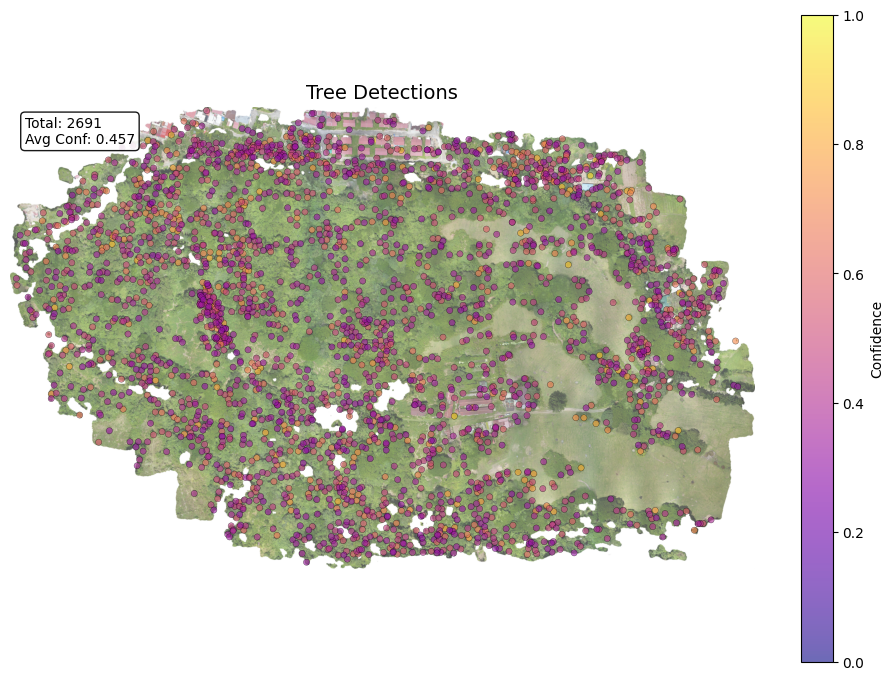

✓ Saved GeoJSON

DETECTION SUMMARY
Total detections: 2691
Average confidence: 0.457
Confidence range: 0.300 - 0.922
Memory usage: 0.27 MB (estimated)

SAVED FILES
✓ tree_detections.csv
✓ tree_points.geojson
✓ tree_boxes.csv
✓ tile_counts.csv
✓ tree_detections.png

CPU time used: 212.56 seconds
Processing speed: 12.7 detections/sec


In [ ]:
# Enable memory efficient settings
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('medium')

start_cpu_time = time.process_time()

# Load model with optimizations
new_model = YOLO('/content/drive/MyDrive/AGRI/Tree_Detection/models/yolo11n-100epoch-v2.pt')
new_model.fuse()  # Fuse layers for inference speed
new_model.to('cuda' if torch.cuda.is_available() else 'cpu')

# Use half precision if GPU is available
if torch.cuda.is_available():
    new_model.half()

def detect_single_resolution_optimized(image_path, model, output_dir, tile_size=1280, overlap=0,
                                       resolution=0.50, conf_threshold=0.20, batch_size=4):
    all_points = []
    detection_points_pixel = []
    detection_boxes = []
    counts_per_tile = []

    try:
        with rasterio.open(image_path) as src:
            original_width, original_height = src.width, src.height
            transform = src.transform
            crs = src.crs

            print(f"Original image size: {original_width}x{original_height}")

            # Calculate new dimensions
            new_width = int(original_width * resolution)
            new_height = int(original_height * resolution)
            print(f"Scaled image size: {new_width}x{new_height}")

            # Memory-efficient reading - process bands sequentially
            # Read only necessary bands
            band_data = []
            for band_idx in [1, 2, 3]:  # RGB bands only
                band = src.read(band_idx)
                # Resize
                band_resized = cv2.resize(band, (new_width, new_height),
                                         interpolation=cv2.INTER_LINEAR)
                band_data.append(band_resized)

            # Stack bands and convert to uint8
            resized_image = np.stack(band_data, axis=-1).astype(np.uint8)

            # Clear temporary variables
            del band_data
            gc.collect()

            # Calculate tile positions
            step = tile_size - overlap
            tile_positions = []

            # Pre-allocate arrays with numpy for faster operations
            y_positions = np.arange(0, new_height, step)
            x_positions = np.arange(0, new_width, step)

            for y in y_positions:
                for x in x_positions:
                    x_end = min(x + tile_size, new_width)
                    y_end = min(y + tile_size, new_height)
                    if x_end - x > 32 and y_end - y > 32:  # Skip very small tiles
                        tile_positions.append((x, y, x_end, y_end))

            print(f"Processing {len(tile_positions)} tiles...")

            # Process tiles in batches for better GPU utilization
            for batch_start in tqdm(range(0, len(tile_positions), batch_size),
                                   desc="Processing batches"):
                batch_end = min(batch_start + batch_size, len(tile_positions))
                batch_tiles = []
                batch_info = []

                # Prepare batch
                for idx in range(batch_start, batch_end):
                    x, y, x_end, y_end = tile_positions[idx]
                    win_w = x_end - x
                    win_h = y_end - y

                    # Extract tile
                    tile = resized_image[y:y_end, x:x_end].copy()  # Copy to avoid view issues

                    if tile.shape[:2] != (tile_size, tile_size):
                        tile = cv2.resize(tile, (tile_size, tile_size))
                        scale_x = win_w / tile_size
                        scale_y = win_h / tile_size
                    else:
                        scale_x = scale_y = 1.0

                    batch_tiles.append(tile)
                    batch_info.append({
                        'idx': idx,
                        'x': x, 'y': y,
                        'scale_x': scale_x,
                        'scale_y': scale_y,
                        'win_w': win_w,
                        'win_h': win_h
                    })

                # Batch prediction - much faster than individual predictions
                if batch_tiles:
                    try:
                        results = model.predict(batch_tiles, conf=conf_threshold,
                                              save=False, verbose=False,
                                              imgsz=tile_size, max_det=300)

                        # Process each result in batch
                        for i, result in enumerate(results):
                            info = batch_info[i]
                            tile_id = info['idx']

                            if result.boxes is not None and len(result.boxes) > 0:
                                # Get boxes and confidences in one go
                                boxes = result.boxes.xyxy.cpu().numpy()
                                confidences = result.boxes.conf.cpu().numpy()
                                detection_count = len(boxes)

                                # Vectorized operations - much faster than loops
                                # Scale boxes
                                bx_scaled = boxes * np.array([info['scale_x'], info['scale_y'],
                                                              info['scale_x'], info['scale_y']])

                                # Calculate centers
                                centers_x = (bx_scaled[:, 0] + bx_scaled[:, 2]) / 2
                                centers_y = (bx_scaled[:, 1] + bx_scaled[:, 3]) / 2

                                # Calculate global coordinates
                                global_x = info['x'] + centers_x
                                global_y = info['y'] + centers_y

                                # Convert to original coordinates
                                original_x = global_x / resolution
                                original_y = global_y / resolution

                                # Calculate widths and heights
                                widths = (bx_scaled[:, 2] - bx_scaled[:, 0]) / (2 * resolution)
                                heights = (bx_scaled[:, 3] - bx_scaled[:, 1]) / (2 * resolution)

                                # Process all detections at once
                                for j in range(len(boxes)):
                                    px, py = rasterio.transform.xy(transform,
                                                                  original_y[j],
                                                                  original_x[j])

                                    detection_points_pixel.append({
                                        'x': float(original_x[j]),
                                        'y': float(original_y[j]),
                                        'confidence': float(confidences[j]),
                                        'tile_id': tile_id
                                    })

                                    all_points.append(Point(float(px), float(py)))

                                    detection_boxes.append({
                                        'x1': float(original_x[j] - widths[j]),
                                        'y1': float(original_y[j] - heights[j]),
                                        'x2': float(original_x[j] + widths[j]),
                                        'y2': float(original_y[j] + heights[j]),
                                        'confidence': float(confidences[j]),
                                        'tile_id': tile_id
                                    })

                                counts_per_tile.append({
                                    "tile_id": tile_id,
                                    "count": detection_count,
                                    "x": info['x'], "y": info['y'],
                                    "width": info['win_w'], "height": info['win_h']
                                })
                            else:
                                counts_per_tile.append({
                                    "tile_id": tile_id,
                                    "count": 0,
                                    "x": info['x'], "y": info['y'],
                                    "width": info['win_w'], "height": info['win_h']
                                })

                    except Exception as e:
                        print(f"Error processing batch {batch_start//batch_size}: {e}")
                        continue

                # Clear batch memory
                del batch_tiles, results
                gc.collect()

                # Optional: Clear GPU cache if using GPU
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

    except Exception as e:
        print(f"Error in detection: {e}")
        raise

    print(f"\nTotal detections: {len(detection_points_pixel)}")
    return all_points, detection_points_pixel, detection_boxes, counts_per_tile


def visualize_detections_efficient(image_path, detection_points_pixel, output_dir,
                                   bands=[1, 2, 3], sample_fraction=1.0):
    """
    Efficient visualization with downsampling option
    """
    if not detection_points_pixel:
        print("No detections to visualize")
        return

    fig, ax = plt.subplots(figsize=(12, 12))
    ax.set_title("Tree Detections", fontsize=14)
    ax.set_axis_off()

    try:
        with rasterio.open(image_path) as src:
            width, height = src.width, src.height

            # Downsample the background for faster plotting
            max_display_pixels = 2000 * 2000
            if width * height > max_display_pixels:
                scale = np.sqrt(max_display_pixels / (width * height))
                display_width = int(width * scale)
                display_height = int(height * scale)

                # Read and resize
                background_img = src.read(bands)
                background_img = np.transpose(background_img, (1, 2, 0))
                background_img = cv2.resize(background_img, (display_width, display_height),
                                          interpolation=cv2.INTER_AREA)
                # Scale coordinates for display
                x_scale = display_width / width
                y_scale = display_height / height

                # Extract coordinates with sampling
                if sample_fraction < 1.0:
                    sample_size = int(len(detection_points_pixel) * sample_fraction)
                    indices = np.random.choice(len(detection_points_pixel),
                                              sample_size, replace=False)
                    x_coords = [detection_points_pixel[i]['x'] * x_scale for i in indices]
                    y_coords = [detection_points_pixel[i]['y'] * y_scale for i in indices]
                    confidences = [detection_points_pixel[i]['confidence'] for i in indices]
                else:
                    x_coords = [d['x'] * x_scale for d in detection_points_pixel]
                    y_coords = [d['y'] * y_scale for d in detection_points_pixel]
                    confidences = [d['confidence'] for d in detection_points_pixel]

                ax.imshow(background_img / 255.0, extent=[0, display_width, display_height, 0],
                         alpha=0.7)
                ax.set_xlim(0, display_width)
                ax.set_ylim(display_height, 0)

            else:
                # Original size
                background_img = src.read(bands)
                background_img = np.transpose(background_img, (1, 2, 0))

                if sample_fraction < 1.0:
                    sample_size = int(len(detection_points_pixel) * sample_fraction)
                    indices = np.random.choice(len(detection_points_pixel),
                                              sample_size, replace=False)
                    x_coords = [detection_points_pixel[i]['x'] for i in indices]
                    y_coords = [detection_points_pixel[i]['y'] for i in indices]
                    confidences = [detection_points_pixel[i]['confidence'] for i in indices]
                else:
                    x_coords = [d['x'] for d in detection_points_pixel]
                    y_coords = [d['y'] for d in detection_points_pixel]
                    confidences = [d['confidence'] for d in detection_points_pixel]

                ax.imshow(background_img / 255.0, extent=[0, width, height, 0], alpha=0.7)
                ax.set_xlim(0, width)
                ax.set_ylim(height, 0)

            # Create scatter plot
            scatter = ax.scatter(x_coords, y_coords, c=confidences, cmap='plasma',
                               s=20, alpha=0.6, edgecolors='black', linewidths=0.3,
                               vmin=0, vmax=1)

            plt.colorbar(scatter, ax=ax, label='Confidence', shrink=0.7)

            avg_conf = np.mean(confidences)
            stats_text = f"Total: {len(detection_points_pixel)}\nAvg Conf: {avg_conf:.3f}"
            if sample_fraction < 1.0:
                stats_text += f"\nDisplayed: {len(x_coords)}"

            ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=10,
                   verticalalignment='top', bbox=dict(boxstyle="round", fc="white", alpha=0.9))

    except Exception as e:
        print(f"Error in visualization: {e}")
        plt.close()
        return

    # Save with compression
    plt.savefig(f'{output_dir}/tree_detections.png', dpi=150, bbox_inches='tight', pil_kwargs={'compress_level': 6})
    plt.show()
    plt.close()


# Configuration
tile_size = 1280
overlap = 0
resolution = 0.50
conf_threshold = 0.30
batch_size = 4  # Process multiple tiles at once
bands = [1, 2, 3]
image_path = '/content/drive/MyDrive/AGRI/TreeCrown_Segmentation/ortho_872.tif'
output_dir = '/content/drive/MyDrive/AGRI/Detection'

print(f"Starting optimized tree detection at {resolution}x resolution...")
print(f"Batch size: {batch_size}")

# Clear cache before starting
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Run detection
all_points, detection_points_pixel, detection_boxes, counts_per_tile = detect_single_resolution_optimized(
    image_path=image_path,
    model=new_model,
    output_dir=output_dir,
    tile_size=tile_size,
    overlap=overlap,
    resolution=resolution,
    conf_threshold=conf_threshold,
    batch_size=batch_size
)

print("\nDetection complete! Creating visualization...")

# Create efficient visualization (display only 20% of points if many)
if len(detection_points_pixel) > 5000:
    sample_frac = 5000 / len(detection_points_pixel)
    print(f"Large dataset ({len(detection_points_pixel)} points), displaying {5000} samples")
else:
    sample_frac = 1.0

visualize_detections_efficient(image_path, detection_points_pixel, output_dir,
                              bands, sample_fraction=sample_frac)

# Save results with memory efficiency
if detection_points_pixel:
    # Convert to DataFrames in chunks to avoid memory issues
    chunk_size = 50000

    # Save detection points in chunks if large
    if len(detection_points_pixel) > chunk_size:
        for i in range(0, len(detection_points_pixel), chunk_size):
            chunk = detection_points_pixel[i:i+chunk_size]
            df_chunk = pd.DataFrame(chunk)
            mode = 'w' if i == 0 else 'a'
            header = i == 0
            df_chunk.to_csv(f'{output_dir}/tree_detections.csv',
                          index=False, mode=mode, header=header)
    else:
        df_detections = pd.DataFrame(detection_points_pixel)
        df_detections.to_csv(f'{output_dir}/tree_detections.csv', index=False)

    # Save as GeoJSON (simplify geometry if large)
    if all_points:
        if len(all_points) > 100000:
            print("Large point set, simplifying...")
            # Keep only every 10th point for very large datasets
            all_points = all_points[::10]
            detection_points_pixel = detection_points_pixel[::10]

        gdf_points = gpd.GeoDataFrame(geometry=all_points, crs='EPSG:4326')
        gdf_points['confidence'] = [d['confidence'] for d in detection_points_pixel]
        gdf_points['tile_id'] = [d['tile_id'] for d in detection_points_pixel]

        try:
            # Save with compression
            gdf_points.to_file(f"{output_dir}/tree_points.geojson",
                             driver="GeoJSON")
            print("✓ Saved GeoJSON")
        except Exception as e:
            print(f"⚠ Could not save GeoJSON: {e}")
            # Try saving as shapefile instead
            try:
                gdf_points.to_file(f"{output_dir}/tree_points.shp")
                print("✓ Saved as Shapefile instead")
            except Exception as e2:
                print(f"⚠ Could not save shapefile either: {e2}")

    # Save other results
    if detection_boxes:
        pd.DataFrame(detection_boxes).to_csv(f'{output_dir}/tree_boxes.csv', index=False)

    if counts_per_tile:
        pd.DataFrame(counts_per_tile).to_csv(f'{output_dir}/tile_counts.csv', index=False)

# Print summary
print(f"\n{'='*50}")
print(f"DETECTION SUMMARY")
print(f"{'='*50}")
print(f"Total detections: {len(detection_points_pixel)}")
if detection_points_pixel:
    confidences = [d['confidence'] for d in detection_points_pixel]
    avg_conf = np.mean(confidences)
    print(f"Average confidence: {avg_conf:.3f}")
    print(f"Confidence range: {min(confidences):.3f} - {max(confidences):.3f}")
    print(f"Memory usage: {len(detection_points_pixel) * 100 / 1e6:.2f} MB (estimated)")

print(f"\n{'='*50}")
print(f"SAVED FILES")
print(f"{'='*50}")
print(f"✓ tree_detections.csv")
print(f"✓ tree_points.geojson")
print(f"✓ tree_boxes.csv")
print(f"✓ tile_counts.csv")
print(f"✓ tree_detections.png")

end_cpu_time = time.process_time()
cpu_time_used = end_cpu_time - start_cpu_time
print(f"\n{'='*50}")
print(f"CPU time used: {cpu_time_used:.2f} seconds")
print(f"Processing speed: {len(detection_points_pixel)/cpu_time_used:.1f} detections/sec")
print(f"{'='*50}")

# Final cleanup
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()